In [202]:
import pandas as pd
import numpy as np
import datetime
from time import strftime
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [203]:
data = pd.read_csv('Data EDA.csv')

In [204]:
data

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [205]:
data.shape

(110527, 14)

In [206]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [207]:
data.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


## Modifying the dataset

In [209]:
data['ScheduledDay'] = pd.to_datetime(data['ScheduledDay']).dt.date.astype('datetime64[ns]')
data['AppointmentDay'] = pd.to_datetime(data['AppointmentDay']).dt.date.astype('datetime64[ns]')

In [210]:
data.head(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## for ScheduledDay & AppointmentDay lets store weekdays in a variable	

In [212]:
data['s_wday'] = data['ScheduledDay'].dt.dayofweek

In [213]:
data['ap_wday'] = data['AppointmentDay'].dt.dayofweek

In [214]:
data['s_wday'].value_counts()

s_wday
1    26168
2    24262
0    23085
4    18915
3    18073
5       24
Name: count, dtype: int64

In [215]:
data['ap_wday'].value_counts()

ap_wday
2    25867
1    25640
0    22715
4    19019
3    17247
5       39
Name: count, dtype: int64

In [216]:
data.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show',
       's_wday', 'ap_wday'],
      dtype='object')

## Modifying the dataset by giving proper column names 

In [218]:
data= data.rename(columns={'Hipertension': 'Hypertension', 'Handcap': 'Handicap', 'SMS_received': 'SMSReceived', 'No-show': 'NoShow'})

In [219]:
data.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMSReceived', 'NoShow', 's_wday',
       'ap_wday'],
      dtype='object')

 ## Removing some columns which are not important

In [221]:
data.drop(['AppointmentID', 'Neighbourhood','PatientId'], axis=1, inplace=True)

In [222]:
data.head(5)

,Gender,ScheduledDay,AppointmentDay,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,NoShow,s_wday,ap_wday
0,F,2016-04-29,2016-04-29,62,0,1,0,0,0,0,No,4,4
1,M,2016-04-29,2016-04-29,56,0,0,0,0,0,0,No,4,4
2,F,2016-04-29,2016-04-29,62,0,0,0,0,0,0,No,4,4
3,F,2016-04-29,2016-04-29,8,0,0,0,0,0,0,No,4,4
4,F,2016-04-29,2016-04-29,56,0,1,1,0,0,0,No,4,4


In [223]:
data.describe()

,ScheduledDay,AppointmentDay,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,s_wday,ap_wday
count,110527,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,2016-05-08 20:33:18.179630080,2016-05-19 00:57:50.008233472,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,1.851955,1.858243
min,2015-11-10 00:00:00,2016-04-29 00:00:00,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-04-29 00:00:00,2016-05-09 00:00:00,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,2016-05-10 00:00:00,2016-05-18 00:00:00,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000
75%,2016-05-20 00:00:00,2016-05-31 00:00:00,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,3.000000
max,2016-06-08 00:00:00,2016-06-08 00:00:00,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,5.000000,5.000000
std,NaN,NaN,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,1.378520,1.371672


# Check for Distribution of Appointment No-Shows

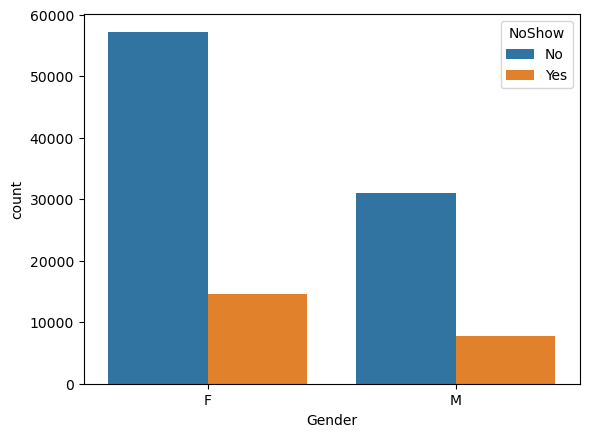

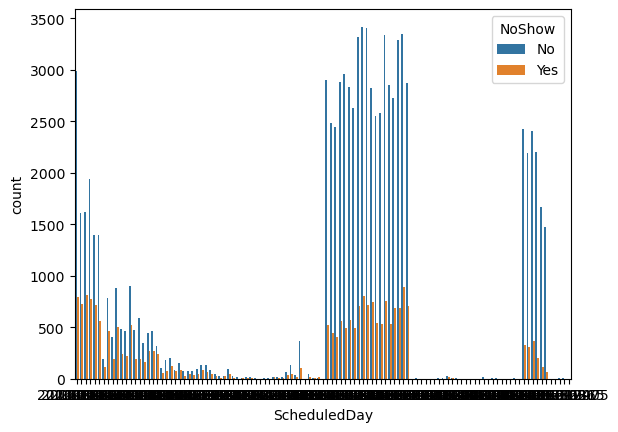

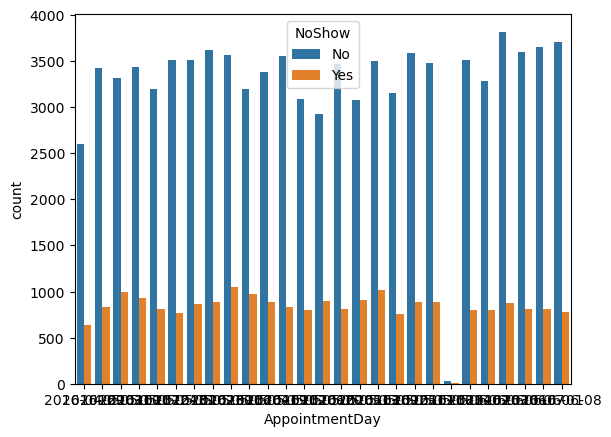

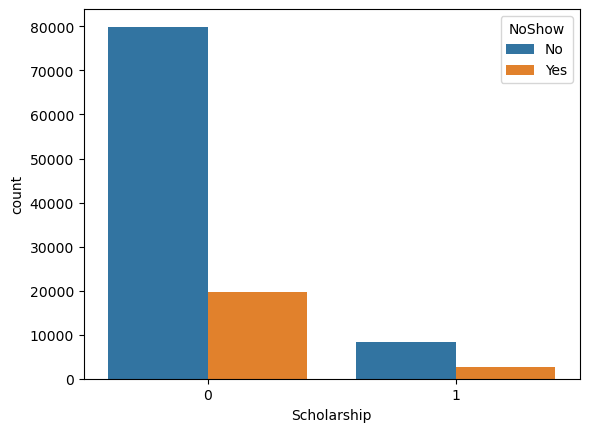

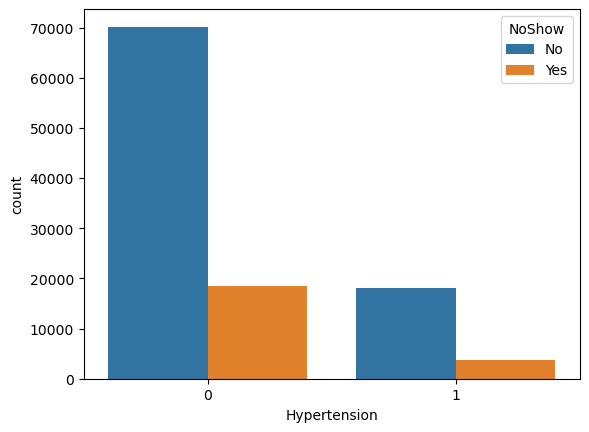

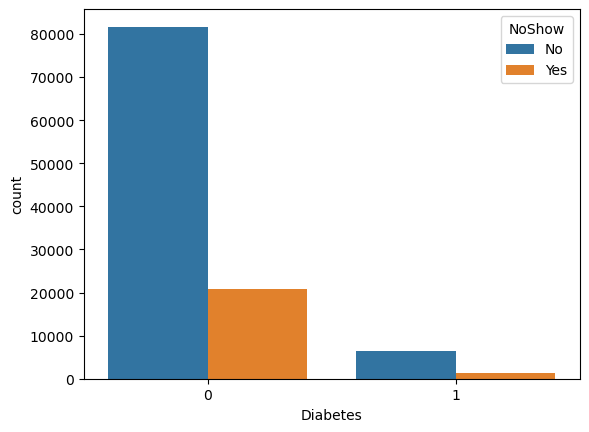

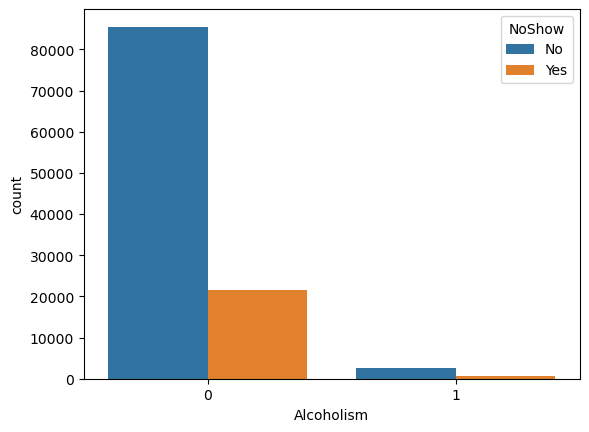

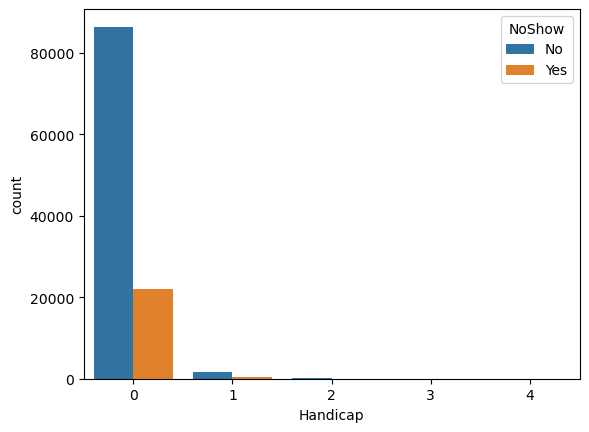

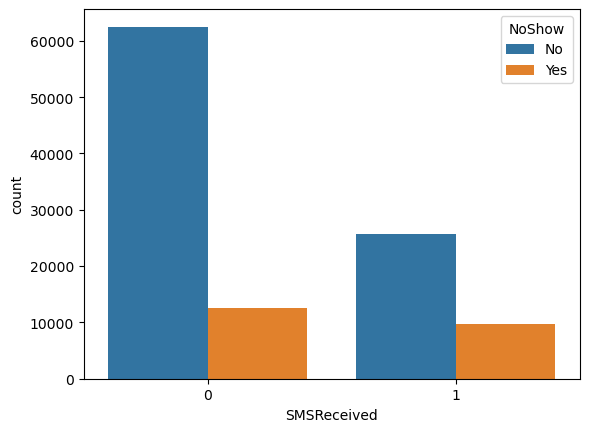

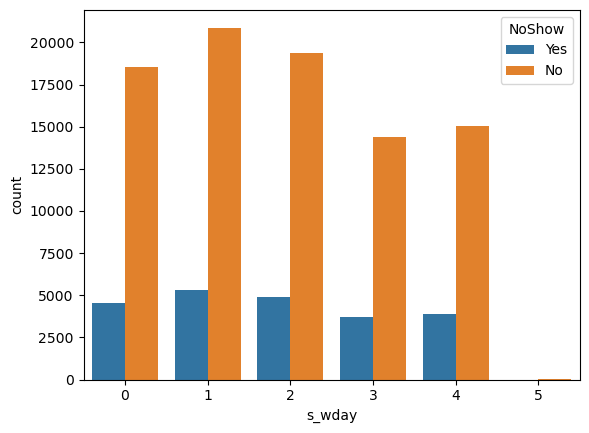

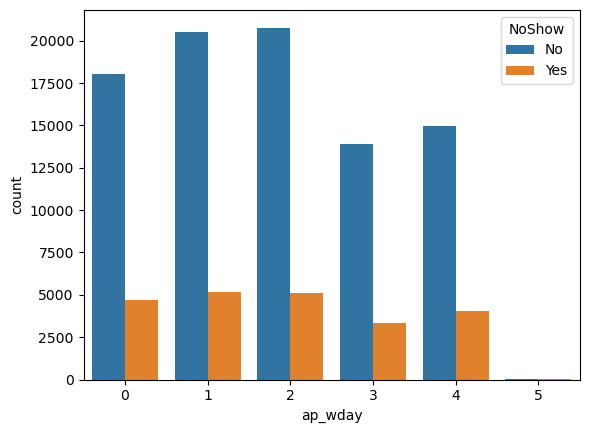

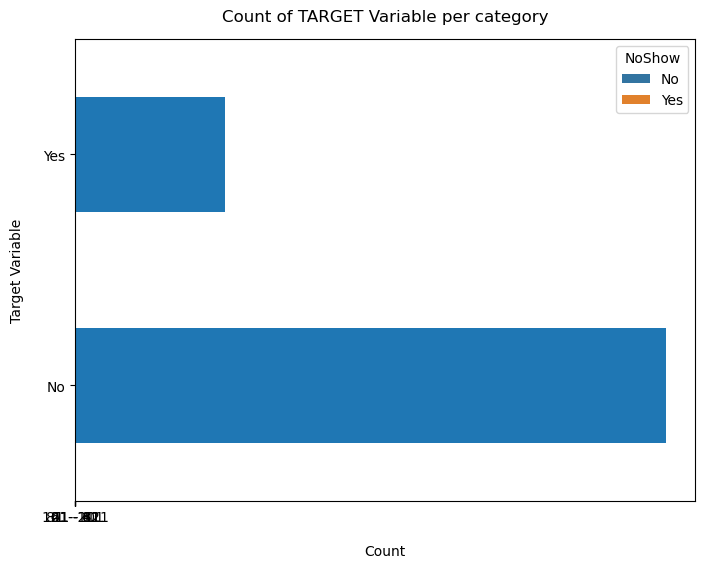

In [225]:
data['NoShow'].value_counts().plot(kind='barh', figsize=(8, 6))
plt.xlabel("Count", labelpad=14)
plt.ylabel("Target Variable", labelpad=14)
plt.title("Count of TARGET Variable per category", y=1.02);
plt.show()

#The "NoShow" (Yes) category represents a smaller portion of the dataset.

## Exact percentage of no-shows

In [228]:
100*data['NoShow'].value_counts()/len(data['NoShow'])

NoShow
No     79.806744
Yes    20.193256
Name: count, dtype: float64

#The dataset is imbalanced, with 79.8% of patients attending their appointments ("No") and 20.2% missing them ("Yes").

## Having a look that data contains missing values or not

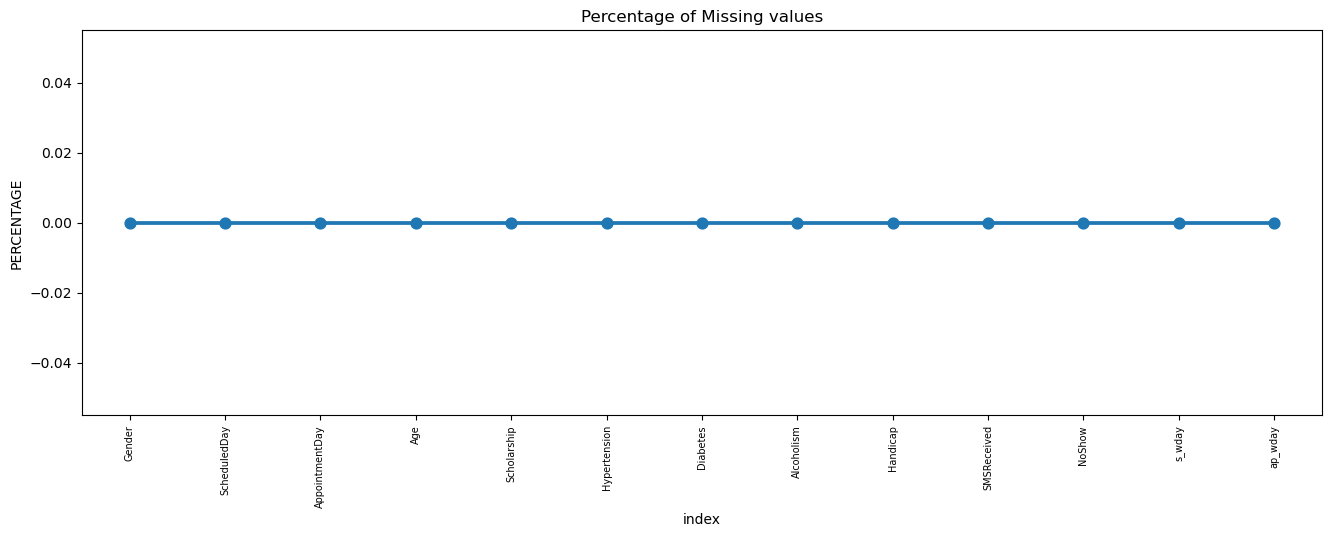

In [231]:
missing = pd.DataFrame((data.isnull().sum()) * 100 / data.shape[0]).reset_index()
plt.figure(figsize=(16, 5))
ax = sns.pointplot(x='index', y=0, data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

#No missing values.

# DATA Cleaning

In [234]:
new_data=data.copy()

In [235]:
new_data.head(2)

,Gender,ScheduledDay,AppointmentDay,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,NoShow,s_wday,ap_wday
0,F,2016-04-29,2016-04-29,62,0,1,0,0,0,0,No,4,4
1,M,2016-04-29,2016-04-29,56,0,0,0,0,0,0,No,4,4


In [236]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Gender          110527 non-null  object        
 1   ScheduledDay    110527 non-null  datetime64[ns]
 2   AppointmentDay  110527 non-null  datetime64[ns]
 3   Age             110527 non-null  int64         
 4   Scholarship     110527 non-null  int64         
 5   Hypertension    110527 non-null  int64         
 6   Diabetes        110527 non-null  int64         
 7   Alcoholism      110527 non-null  int64         
 8   Handicap        110527 non-null  int64         
 9   SMSReceived     110527 non-null  int64         
 10  NoShow          110527 non-null  object        
 11  s_wday          110527 non-null  int32         
 12  ap_wday         110527 non-null  int32         
dtypes: datetime64[ns](2), int32(2), int64(7), object(2)
memory usage: 10.1+ MB


#Since there are no null records in this dataset , no cleaning is required further

## Grouping the numerical Age column into categorical buckets (bins) of 20-year intervals.

In [239]:
# The max tenure -
print(data['Age'].max()) 

115


In [240]:
labels = ["{0} - {1}".format(i, i + 20) for i in range(1, 118, 20)]
data['Age_group'] = pd.cut(data.Age, range(1, 130, 20), right=False, labels=labels)

In [241]:
data.drop(['Age'], axis=1, inplace=True)

In [242]:
data

,Gender,ScheduledDay,AppointmentDay,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,NoShow,s_wday,ap_wday,Age_group
0,F,2016-04-29,2016-04-29,0,1,0,0,0,0,No,4,4,61 - 81
1,M,2016-04-29,2016-04-29,0,0,0,0,0,0,No,4,4,41 - 61
2,F,2016-04-29,2016-04-29,0,0,0,0,0,0,No,4,4,61 - 81
3,F,2016-04-29,2016-04-29,0,0,0,0,0,0,No,4,4,1 - 21
4,F,2016-04-29,2016-04-29,0,1,1,0,0,0,No,4,4,41 - 61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,F,2016-05-03,2016-06-07,0,0,0,0,0,1,No,1,1,41 - 61
110523,F,2016-05-03,2016-06-07,0,0,0,0,0,1,No,1,1,41 - 61
110524,F,2016-04-27,2016-06-07,0,0,0,0,0,1,No,2,1,21 - 41
110525,F,2016-04-27,2016-06-07,0,0,0,0,0,1,No,2,1,21 - 41


# DATA Exploration

## Bivariate analysis by looping through all features to display their frequency counts and visualize their relationship with the NoShow target variable using side-by-side count plots.

---------- Gender ----------
Gender
F    71840
M    38687
Name: count, dtype: int64


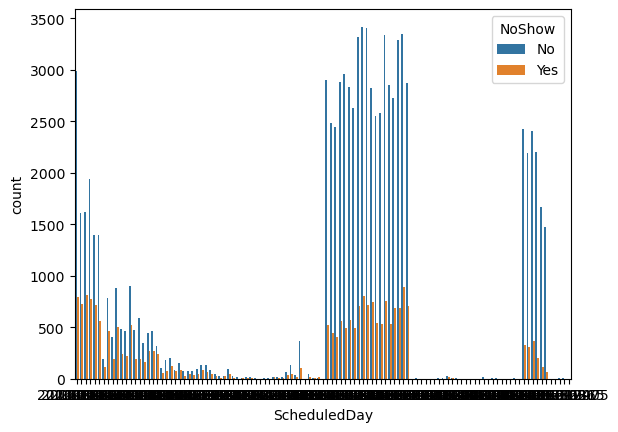

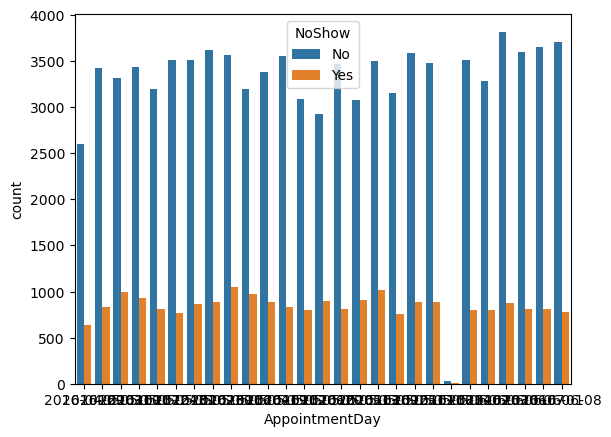

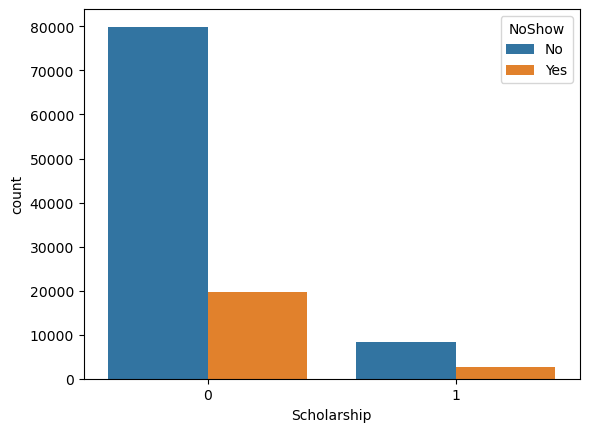

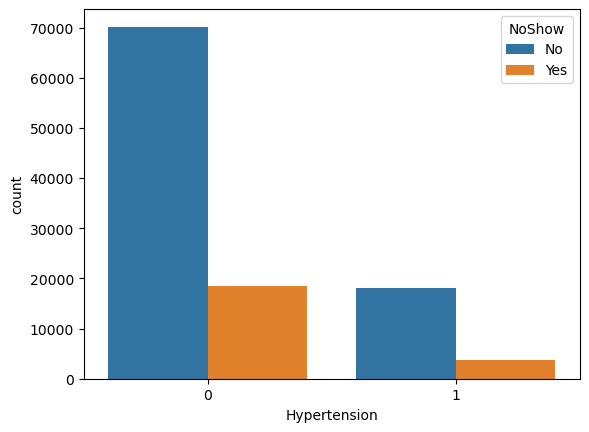

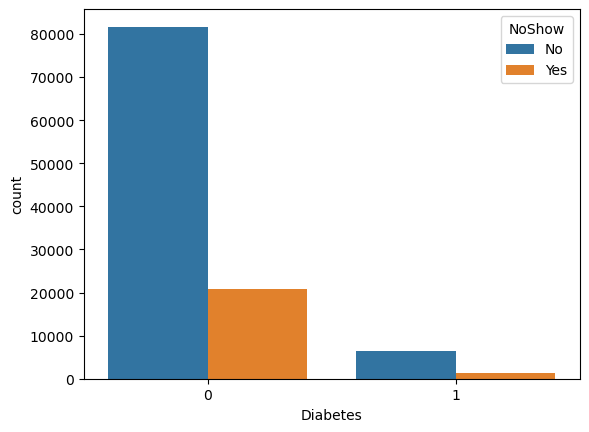

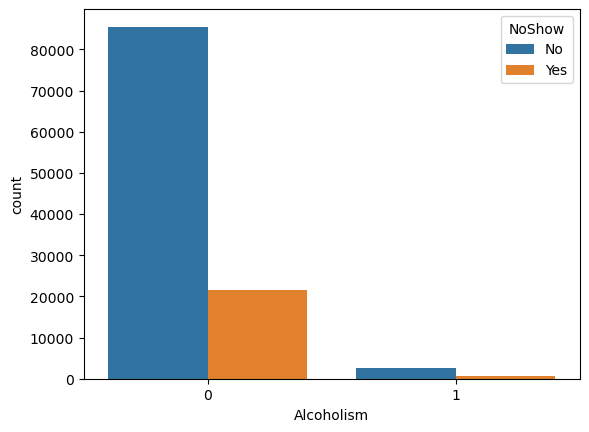

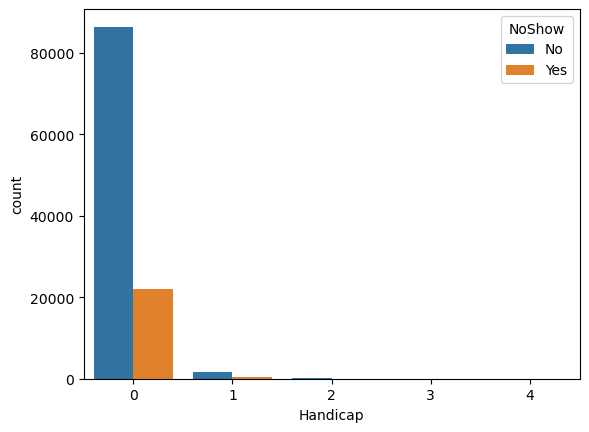

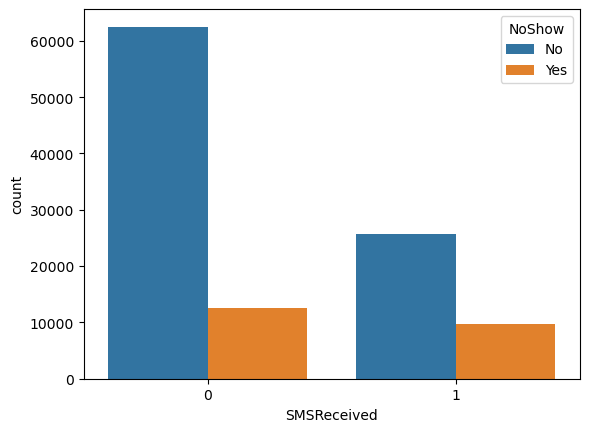

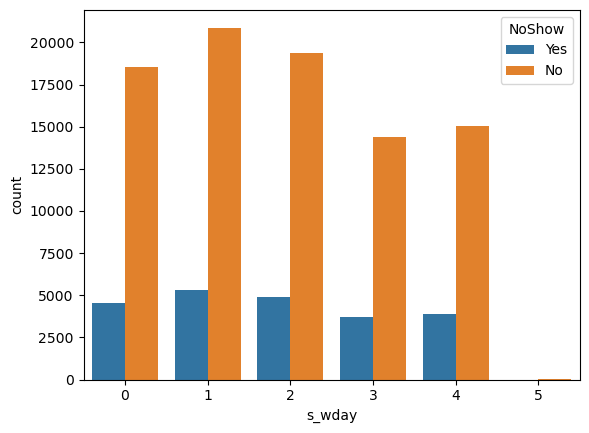

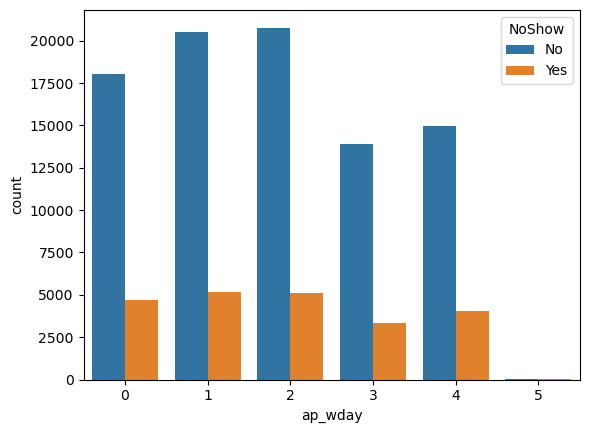

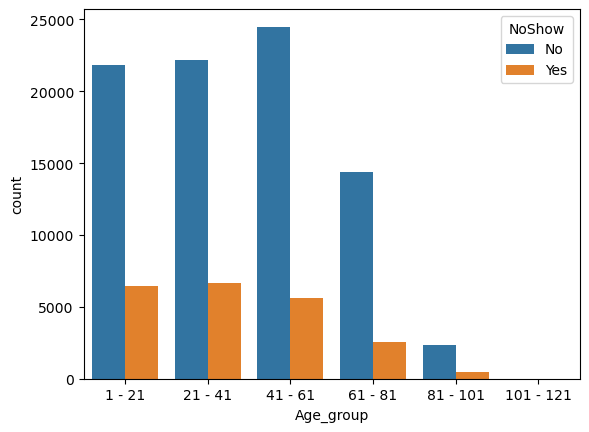

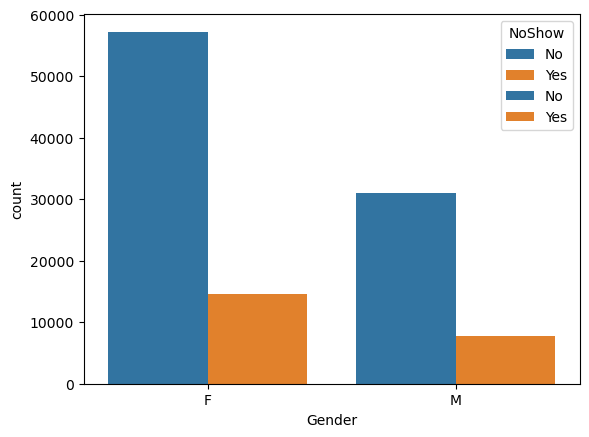

---------- ScheduledDay ----------
ScheduledDay
2016-05-03    4238
2016-05-02    4216
2016-05-16    4120
2016-05-05    4095
2016-05-10    4024
              ... 
2016-04-16       1
2016-01-28       1
2015-11-10       1
2016-03-19       1
2016-03-05       1
Name: count, Length: 111, dtype: int64


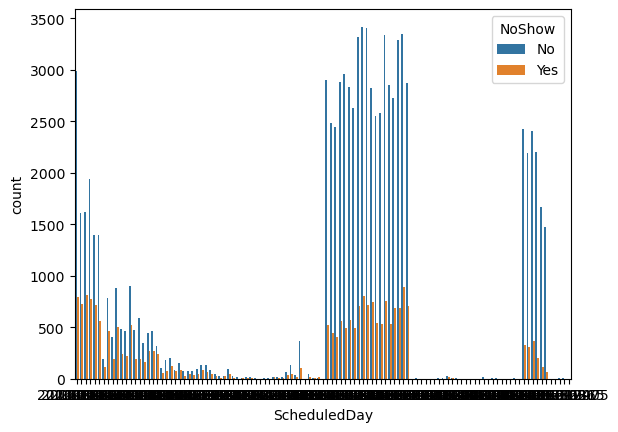

---------- AppointmentDay ----------
AppointmentDay
2016-06-06    4692
2016-05-16    4613
2016-05-09    4520
2016-05-30    4514
2016-06-08    4479
2016-05-11    4474
2016-06-01    4464
2016-06-07    4416
2016-05-12    4394
2016-05-02    4376
2016-05-18    4373
2016-05-17    4372
2016-06-02    4310
2016-05-10    4308
2016-05-31    4279
2016-05-05    4273
2016-05-19    4270
2016-05-03    4256
2016-05-04    4168
2016-06-03    4090
2016-05-24    4009
2016-05-13    3987
2016-05-25    3909
2016-05-06    3879
2016-05-20    3828
2016-04-29    3235
2016-05-14      39
Name: count, dtype: int64


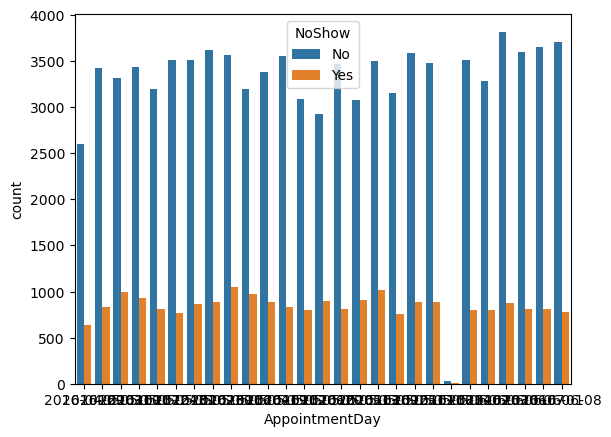

---------- Scholarship ----------
Scholarship
0    99666
1    10861
Name: count, dtype: int64


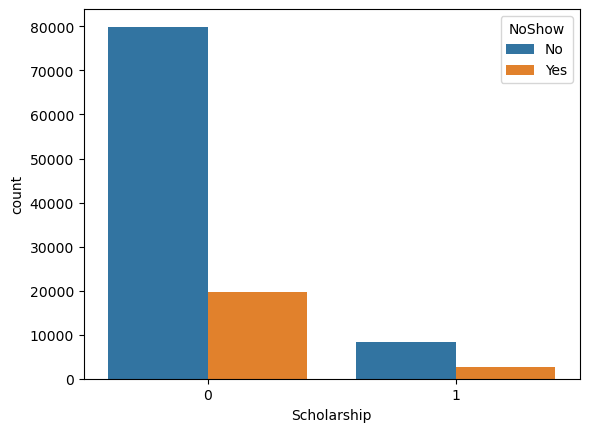

---------- Hypertension ----------
Hypertension
0    88726
1    21801
Name: count, dtype: int64


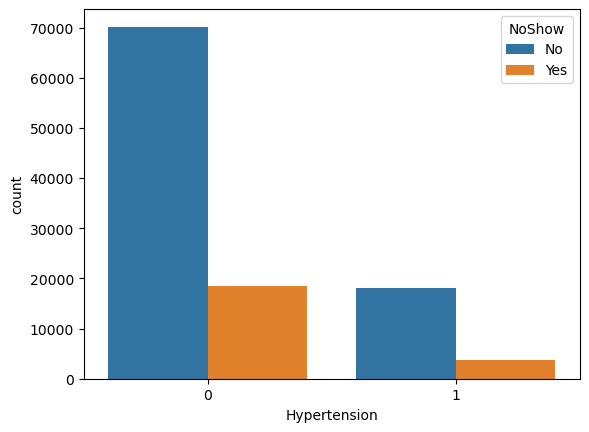

---------- Diabetes ----------
Diabetes
0    102584
1      7943
Name: count, dtype: int64


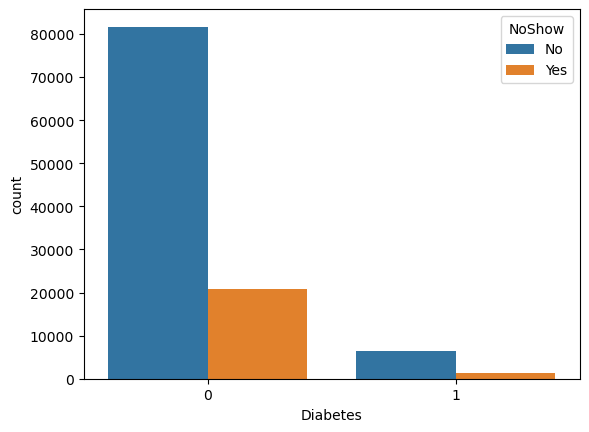

---------- Alcoholism ----------
Alcoholism
0    107167
1      3360
Name: count, dtype: int64


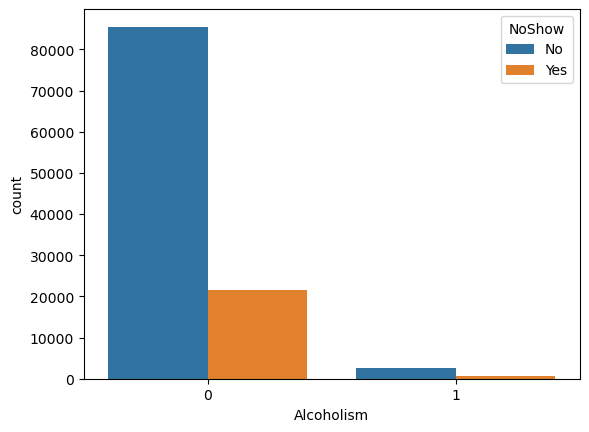

---------- Handicap ----------
Handicap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64


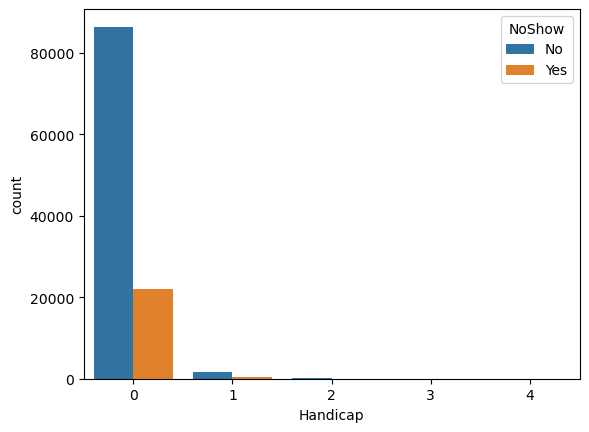

---------- SMSReceived ----------
SMSReceived
0    75045
1    35482
Name: count, dtype: int64


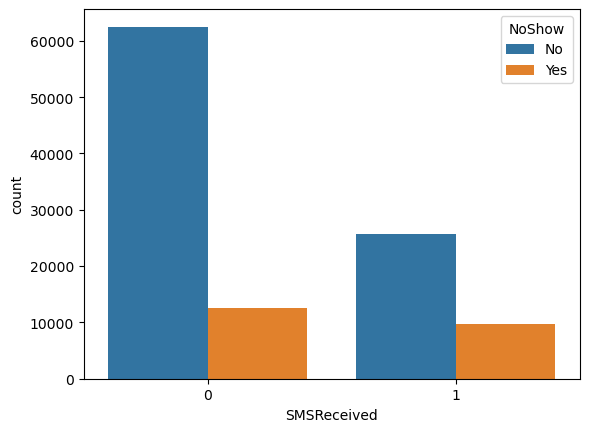

---------- s_wday ----------
s_wday
1    26168
2    24262
0    23085
4    18915
3    18073
5       24
Name: count, dtype: int64


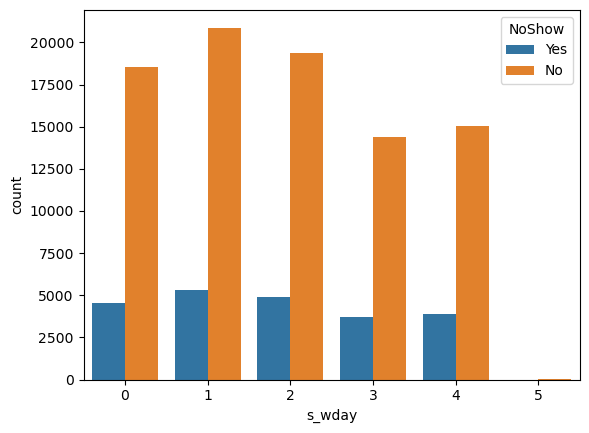

---------- ap_wday ----------
ap_wday
2    25867
1    25640
0    22715
4    19019
3    17247
5       39
Name: count, dtype: int64


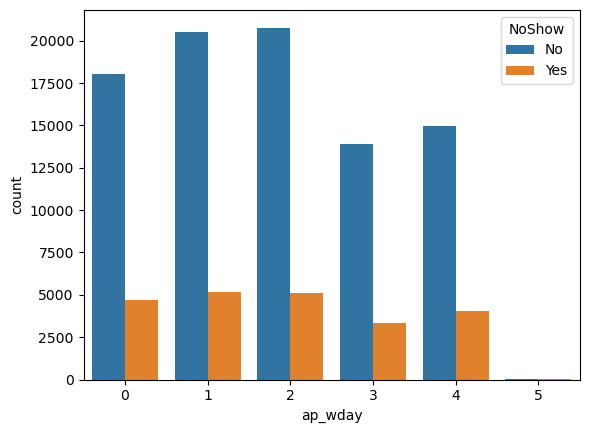

---------- Age_group ----------
Age_group
41 - 61      30081
21 - 41      28835
1 - 21       28309
61 - 81      16910
81 - 101      2845
101 - 121        7
Name: count, dtype: int64


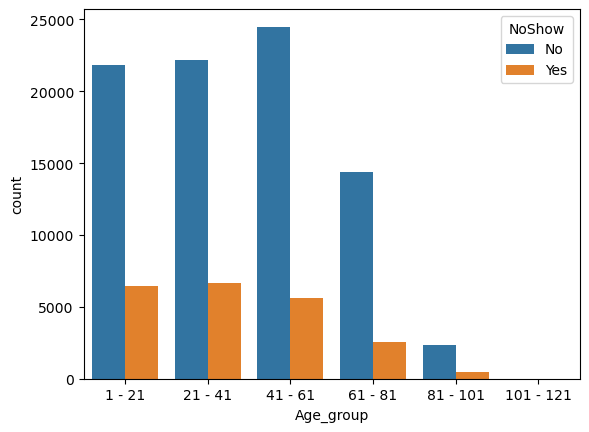

In [277]:
for i, predictor in enumerate(data.drop(columns=['NoShow'])):
    print('-'*10,predictor,'-'*10)
    print(data[predictor].value_counts())    
    plt.figure(i)
    sns.countplot(data=data, x=predictor, hue='NoShow')
    plt.show()


In [280]:
data['NoShow'] = np.where(data.NoShow == 'Yes',1,0)

In [282]:
data.NoShow.value_counts()

NoShow
0    88208
1    22319
Name: count, dtype: int64

## Converting categorical values into dummy variables

In [286]:
data_dummies = pd.get_dummies(data)
data_dummies.head()

,ScheduledDay,AppointmentDay,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,NoShow,s_wday,ap_wday,Gender_F,Gender_M,Age_group_1 - 21,Age_group_21 - 41,Age_group_41 - 61,Age_group_61 - 81,Age_group_81 - 101,Age_group_101 - 121
0,2016-04-29,2016-04-29,0,1,0,0,0,0,0,4,4,True,False,False,False,False,True,False,False
1,2016-04-29,2016-04-29,0,0,0,0,0,0,0,4,4,False,True,False,False,True,False,False,False
2,2016-04-29,2016-04-29,0,0,0,0,0,0,0,4,4,True,False,False,False,False,True,False,False
3,2016-04-29,2016-04-29,0,0,0,0,0,0,0,4,4,True,False,True,False,False,False,False,False
4,2016-04-29,2016-04-29,0,1,1,0,0,0,0,4,4,True,False,False,False,True,False,False,False


## Build a Correlation of all predictors with No-show 

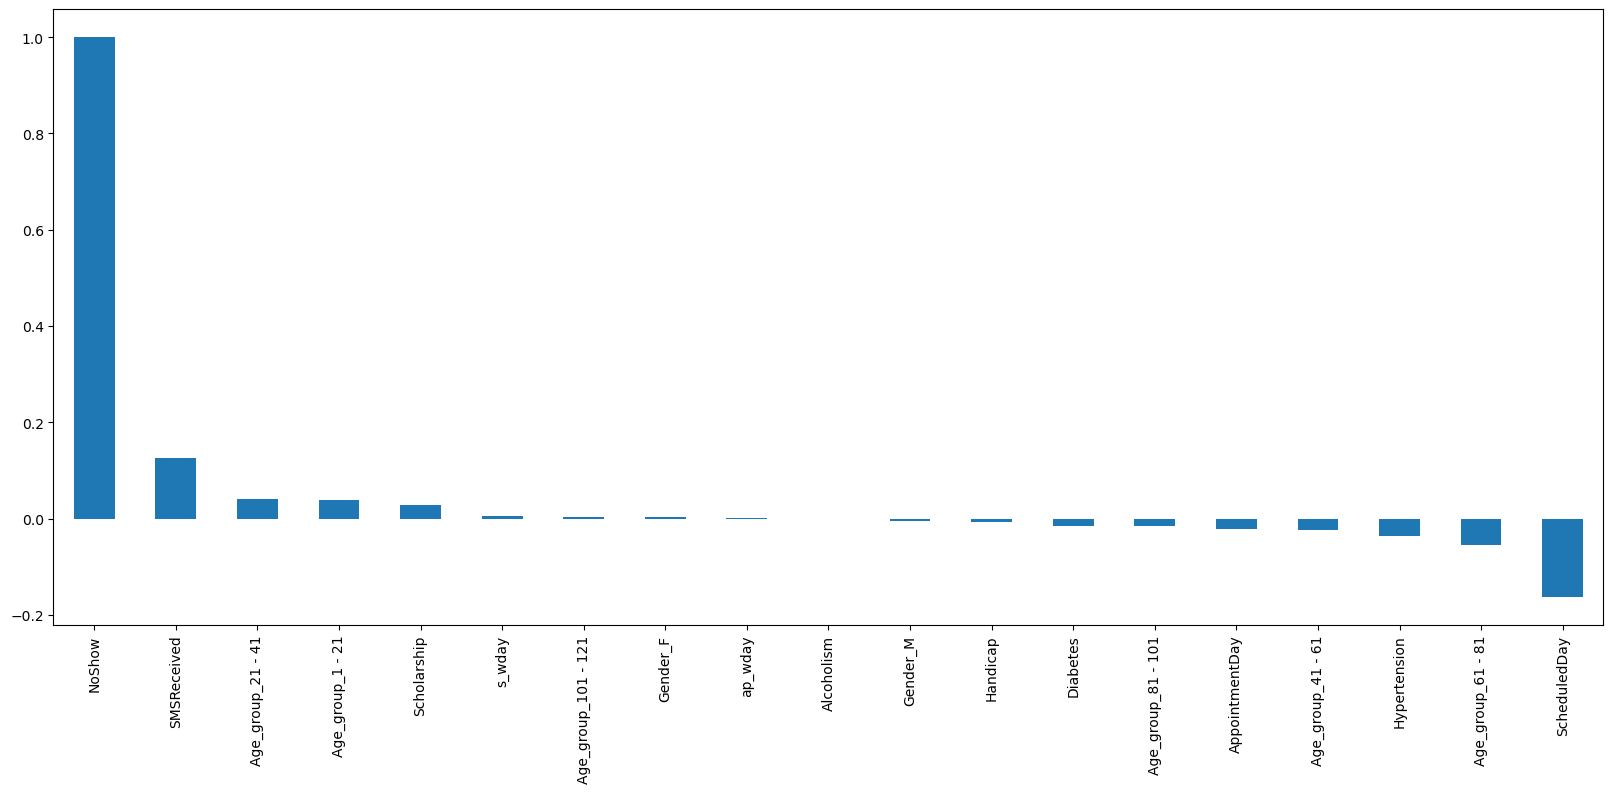

In [291]:
plt.figure(figsize=(20,8))
data_dummies.corr()['NoShow'].sort_values(ascending = False).plot(kind='bar')
plt.show()

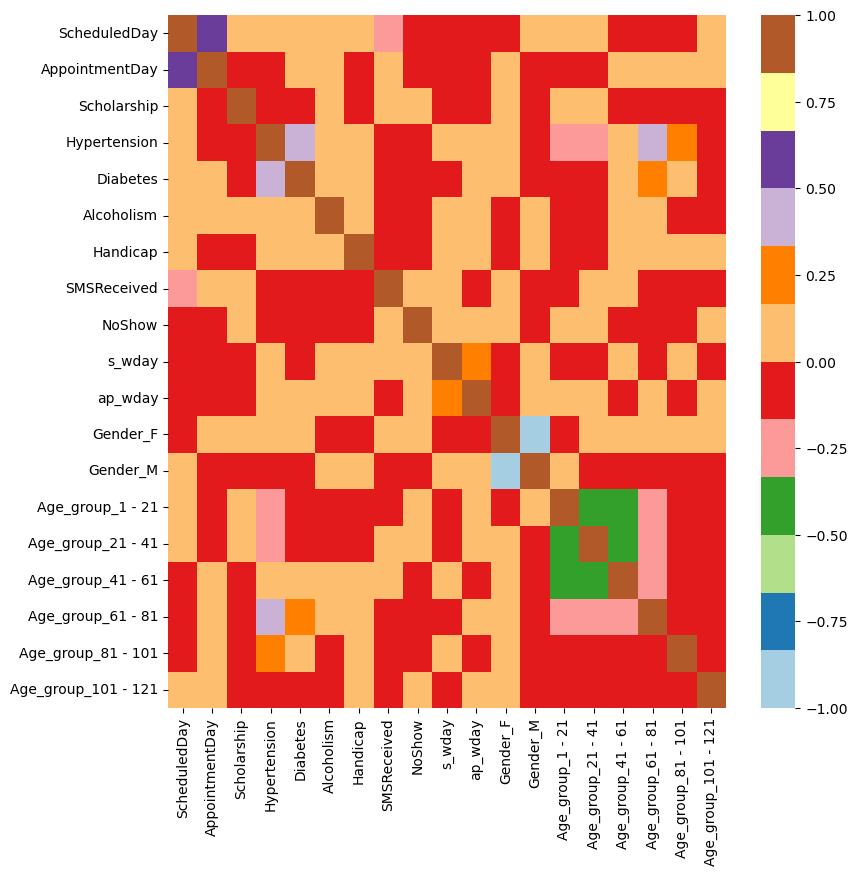

In [297]:
plt.figure(figsize=(9,9))
sns.heatmap(data_dummies.corr(), cmap="Paired")
plt.show()

## Bivariate Analysis

In [304]:
new_df1_target0=data.loc[data["NoShow"]==0]
new_df1_target1=data.loc[data["NoShow"]==1]

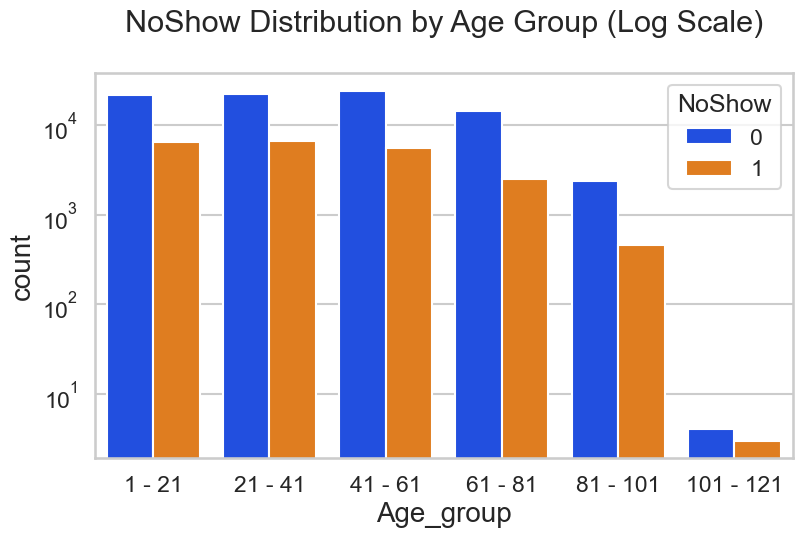

In [314]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=data, x='Age_group', hue='NoShow', palette='bright')
ax.set_yscale("log")
plt.title("NoShow Distribution by Age Group (Log Scale)")
plt.show()

# FINDINGS:-

### 1. Female patients have taken more appointments then male patients
### 2. Ratio of Nohow and Show is almost equal for age group except Age 0 and Age 1 with 80% show rate for each age group
### 3. Each Neighbourhood have almost 80% show rate
### 4. There are 99666 patients without Scholarship and out of them around 80% have come for the visit and out of the 21801 patients with Scholarship around 75% of them have come for the visit.
### 5. Tthere are around 88,726 patients without Hypertension and out of them around 78% have come for the visit and Out of the 21801 patients with Hypertension around 85% of them have come for the visit.
### 6. There are around 102,584 patients without Diabetes and out of them around 80% have come for the visit and Out of the 7,943 patients with Diabetes around 83% of them have come for the visit.
### 7. There are around 75,045 patients who have not received SMS and out of them around 84% have come for the visit and out of the 35,482 patients who have received SMS around 72% of them have come for the visit. 
### 8. There is no appointments on sunday and on saturday appointments are very less in comparision to other week days 
